In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay

In [ ]:
data=load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
df=pd.DataFrame(data.data,columns=data.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [ ]:
x=df
y=data.target

sc=StandardScaler()
x_scaled=sc.fit_transform(x)
x_scaled


array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [ ]:
X=x_scaled
Y=y
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


The dataset was divided into input features and the traget variable.The dataset was then checked the missing values,and no missing values were found .Therefore no imputation was required.Since the features have different numerical scales ,StandardScaler was used to standardize the features. this is particularly important for algorithms such as Logistic Regression,SVM,KNN,which are sensitive to feature scale.The dataset is divided into 80% training data and 20% testing data.The training data is used to train the models and testing data is used to evaluvate the performance

In [ ]:
#Logistic Regression
clf=LogisticRegression(max_iter=10000,random_state=0)
clf.fit(X_train,Y_train)
clf_predict=clf.predict(X_test)
print(accuracy_score(Y_test,clf_predict)*100)

97.36842105263158


In [ ]:
print(classification_report(Y_test,clf_predict))
print(confusion_matrix(Y_test,clf_predict))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

[[41  2]
 [ 1 70]]


* Logistic Regression calculates the probability of an observation belonging to a particular class.
* It is suitable for a binary classification problems,above dataset is binary classification(benign or malignant)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

#Decision Tree Classifier
clf=DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=0
)
clf.fit(X_train,Y_train)
clf_predict=clf.predict(X_test)
print(accuracy_score(Y_test,clf_predict)*100)
print(confusion_matrix(Y_test,clf_predict))
print(classification_report(Y_test,clf_predict))

95.6140350877193
[[39  4]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



* A Decision Tree makes decisions using a series of condition based on the features.
* It is easy to understand and work well with numerical data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
#Random Forest Classifier
rf_classifier=RandomForestClassifier(n_estimators=100,random_state=0)
rf_classifier.fit(X_train,Y_train)
rf_classifier_predict=rf_classifier.predict(X_test)
print(accuracy_score(Y_test,rf_classifier_predict))
print(confusion_matrix(Y_test,rf_classifier_predict))
print(classification_report(Y_test,rf_classifier_predict))

0.9649122807017544
[[40  3]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



* Random Forest works by combaining multiple decision trees to make a final prediction.
* It is suitable for this dataset beacuse it can handle many numerical features and give reliable classification results.

0.956140350877193
[[41  2]
 [ 3 68]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



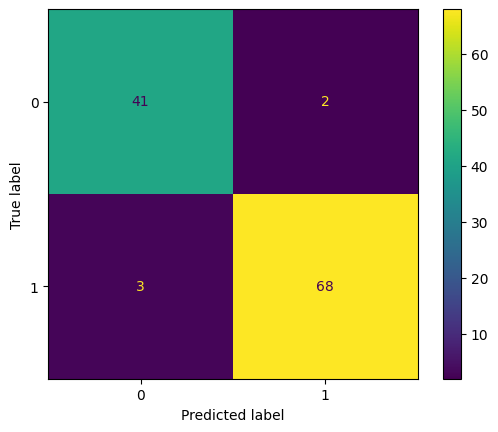

In [ ]:
from sklearn.model_selection import(cross_val_score)
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
import matplotlib.pyplot as plt
#svm
svm_model=SVC(kernel="linear",C=1)
svm_model.fit(X_train,Y_train)
svm_model_predict=svm_model.predict(X_test)
print(accuracy_score(Y_test,svm_model_predict))
print(confusion_matrix(Y_test,svm_model_predict))
print(classification_report(Y_test,svm_model_predict))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_test,svm_model_predict))
disp.plot()
plt.show()

* SVM finds the best boundary to separate different classes.
* It is suitable for the dataset beacuse it works well with numerical features after feature scaling.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
#KNN
knn= KNeighborsClassifier(n_neighbors=5)
knn=knn.fit(X_train,Y_train)
knn_predict=knn.predict(X_test)
print(accuracy_score(Y_test,knn_predict))
print(confusion_matrix(Y_test,knn_predict))
print(classification_report(Y_test,knn_predict))

0.9473684210526315
[[40  3]
 [ 3 68]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



* KNN clssifies a new data point based on its nearest neighbors.
* It  works well with numerical data after feature scaling.

In [ ]:
print("Logistic Regression:",accuracy_score(Y_test,clf_predict))
print("Decision Tree:",accuracy_score(Y_test,clf_predict))
print("Random Forest:",accuracy_score(Y_test,rf_classifier_predict))
print("SVM:",accuracy_score(Y_test,svm_model_predict))
print("KNN:",accuracy_score(Y_test,knn_predict))

Logistic Regression: 0.956140350877193
Decision Tree: 0.956140350877193
Random Forest: 0.9649122807017544
SVM: 0.956140350877193
KNN: 0.9473684210526315


* Random Forest Classifier is the best peforming claasifier because it has  highest accuracy score of 0.964
* KNN is the worst performing because it has the accuracy score of 0.947